Projeler: Senin listenden 7 tane:

Yapay Sinir Ağları ile Görüntü Sınıflandırma (MLP) -yapmıştım tekrar yapmicam

CNN ile Rakam Görüntüsü Sınıflandırma (MNIST) -yapmıştım tekrar yapmicam

LSTM ile Film Yorumları Duygu Analizi

GAN ile Görüntü Oluşturma

Transformers ile Duygu Analizi (Text)

Autoencoder ile Moda Görüntüleri (Fashion-MNIST)

Transfer Learning ile İlaç Görüntüleri Sınıflandırma

**GAN ile Görüntü Oluşturma**

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# MNIST veri seti: 28x28 el yazısı rakamlar
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize: 0-1 arası
x_train = x_train.astype('float32') / 255.0
# 28x28 -> 784 boyut vektör
x_train = x_train.reshape(-1, 28*28)

print("Eğitim verisi shape:", x_train.shape)

Eğitim verisi shape: (60000, 784)


In [13]:
# MNIST veri seti: 28x28 el yazısı rakamlar
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize: 0-1 arası
x_train = x_train.astype('float32') / 255.0
# 28x28 -> 784 boyut vektör
x_train = x_train.reshape(-1, 28*28)

print("Eğitim verisi shape:", x_train.shape)

Eğitim verisi shape: (60000, 784)


In [14]:
def build_generator():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='relu', input_dim=100)) # 100 boyut noise
    model.add(layers.Dense(784, activation='sigmoid')) # 28x28 çıktı
    return model

In [15]:
def build_discriminator():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='relu', input_dim=784))
    model.add(layers.Dense(1, activation='sigmoid')) # gerçek mi sahte mi
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [16]:
# Discriminator'u eğitme, GAN eğitirken dondur
discriminator = build_discriminator()
discriminator.trainable = False

generator = build_generator()

# GAN: Generator + Discriminator
gan_input = layers.Input(shape=(100,))
gan_output = discriminator(generator(gan_input))
gan = models.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

In [17]:
batch_size = 128
epochs = 1000

for epoch in range(epochs):
    # 1️⃣ Gerçek verilerden batch seç
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    # 2️⃣ Sahte görüntü üret
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_imgs = generator.predict(noise, verbose=0)

    # 3️⃣ Etiketler
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    # 4️⃣ Discriminator'u eğit
    d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # 5️⃣ Generator'u eğit (discriminator sabit)
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1))) # generator gerçekmiş gibi sahte üretir

    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")

0 [D loss: 0.5549, acc: 80.08%] [G loss: 0.6980]
100 [D loss: 2.9250, acc: 43.19%] [G loss: 0.0335]
200 [D loss: 3.3320, acc: 43.06%] [G loss: 0.0174]
300 [D loss: 3.5648, acc: 42.96%] [G loss: 0.0118]
400 [D loss: 3.7317, acc: 42.99%] [G loss: 0.0090]
500 [D loss: 3.8631, acc: 43.00%] [G loss: 0.0072]
600 [D loss: 3.9728, acc: 43.00%] [G loss: 0.0061]
700 [D loss: 4.0668, acc: 43.01%] [G loss: 0.0052]
800 [D loss: 4.1497, acc: 43.00%] [G loss: 0.0046]
900 [D loss: 4.2228, acc: 42.98%] [G loss: 0.0041]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


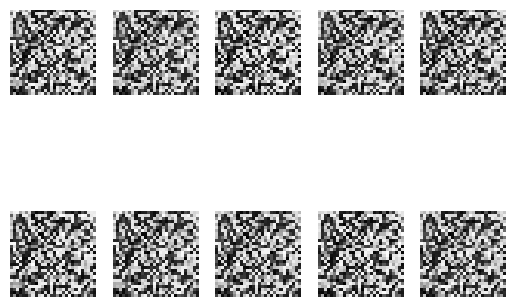

In [18]:
# 10 yeni görüntü üret
noise = np.random.normal(0, 1, (10, 100))
gen_imgs = generator.predict(noise)

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(gen_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()